# Notebook 06 — Machine Learning

**Input:** output thật của Notebook 05 (`features_engineered.parquet`).  
**Main task:** time-based popularity regression.  
**Experiments:** Baseline và Baseline + 13 Engineered Features; mỗi experiment chạy Linear Regression, Random Forest và XGBoost.  
**Output:** metrics mới, predictions, feature importance và một pipeline hoàn chỉnh dùng cho Notebook 07/FastAPI.

In [1]:
from pathlib import Path
import json
import sys
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    for candidate in Path.cwd().resolve().parents:
        if (candidate / "src").exists() and (candidate / "5.DATA").exists():
            ROOT = candidate
            break
sys.path.insert(0, str(ROOT))

from src.features import (
    BASELINE_MODEL_FEATURES,
    EXPECTED_ENGINEERED_FEATURES,
    MODEL_FEATURES,
    RAW_INPUT_FEATURES,
    TARGET,
    TEST_START_YEAR,
    validate_engineered_features,
)
from src.modeling import (
    MODEL_NAMES,
    build_model_pipeline,
    regression_metrics,
    transformed_feature_importance,
)

DATA_PATH = ROOT / "5.DATA" / "processed" / "features_engineered.parquet"
ARTIFACT_DIR = ROOT / "4.MODELS" / "hitradar_popularity"
EVALUATION_DIR = ROOT / "4.MODELS" / "4.2.evaluation"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Minh hieu\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Project root: D:\Hitradar\hitradar-main


## 1. Load NB05 output và kiểm tra feature contract

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Chưa có output NB05: {DATA_PATH}. Không dùng synthetic fallback.")

df = pd.read_parquet(DATA_PATH)
missing_features = [feature for feature in MODEL_FEATURES if feature not in df.columns]
assert not missing_features, f"MODEL_FEATURES chưa tồn tại: {missing_features}"
assert validate_engineered_features(df)["Status"].eq("PASS").all()
assert "cluster" not in MODEL_FEATURES, "Cluster không được tính vào regression features."

train_df = df[df["release_year"] < TEST_START_YEAR].copy()
test_df = df[df["release_year"] >= TEST_START_YEAR].copy()
assert len(train_df) + len(test_df) == len(df)
assert train_df["release_year"].max() < test_df["release_year"].min()

X_train = train_df[RAW_INPUT_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[RAW_INPUT_FEATURES]
y_test = test_df[TARGET]

print(f"Dataset: {df.shape}")
print(f"Train: {X_train.shape}, years {train_df.release_year.min()}–{train_df.release_year.max()}")
print(f"Test:  {X_test.shape}, years {test_df.release_year.min()}–{test_df.release_year.max()}")
print(f"Baseline feature count: {len(BASELINE_MODEL_FEATURES)}")
print(f"Engineered feature count: {len(EXPECTED_ENGINEERED_FEATURES)}")
print(f"Approved MODEL_FEATURES: {len(MODEL_FEATURES)}")

Dataset: (586672, 33)
Train: (554547, 17), years 1900–2018
Test:  (32125, 17), years 2019–2021
Baseline feature count: 18
Engineered feature count: 13
Approved MODEL_FEATURES: 31


## 2. Leakage-safe training pipeline

Mỗi pipeline thực hiện đúng thứ tự: raw input → `FeatureBuilder.fit(train)` → `ColumnTransformer.fit(train)` → estimator. Category features được one-hot encode thật; scaler, imputer, encoder và period statistics không nhìn thấy test.

In [3]:
experiment_specs = [
    ("Baseline", False),
    ("Engineered", True),
]

metrics_rows = []
trained_pipelines = {}
predictions = {}

for experiment, include_engineered in experiment_specs:
    for model_name in MODEL_NAMES:
        print(f"Training {experiment} / {model_name} ...")
        started = time.perf_counter()
        pipeline = build_model_pipeline(model_name, include_engineered=include_engineered)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        metrics = regression_metrics(y_test, y_pred)
        metrics_rows.append(
            {
                "Experiment": experiment,
                "Model": model_name,
                **metrics,
                "Train Rows": len(X_train),
                "Test Rows": len(X_test),
                "Raw Input Features": len(RAW_INPUT_FEATURES),
                "Engineered Features": len(EXPECTED_ENGINEERED_FEATURES) if include_engineered else 0,
                "Runtime Seconds": time.perf_counter() - started,
            }
        )
        trained_pipelines[(experiment, model_name)] = pipeline
        predictions[(experiment, model_name)] = np.asarray(y_pred)
        print(metrics_rows[-1])

metrics_table = pd.DataFrame(metrics_rows).sort_values(["Experiment", "RMSE"])
display(metrics_table)

Training Baseline / Linear Regression ...


{'Experiment': 'Baseline', 'Model': 'Linear Regression', 'MAE': 18.633607075416602, 'RMSE': 22.913068363122186, 'R2': 0.08283377865033903, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 0, 'Runtime Seconds': 4.0150674999999865}
Training Baseline / Random Forest ...


{'Experiment': 'Baseline', 'Model': 'Random Forest', 'MAE': 16.520659303756368, 'RMSE': 20.707796481726756, 'R2': 0.25088356382872157, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 0, 'Runtime Seconds': 31.51989169999979}
Training Baseline / XGBoost ...


{'Experiment': 'Baseline', 'Model': 'XGBoost', 'MAE': 16.313207626342773, 'RMSE': 20.579572367474622, 'R2': 0.2601320743560791, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 0, 'Runtime Seconds': 7.4771725999999035}
Training Engineered / Linear Regression ...


{'Experiment': 'Engineered', 'Model': 'Linear Regression', 'MAE': 18.303899730841966, 'RMSE': 22.69255942072206, 'R2': 0.10040193527037466, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 13, 'Runtime Seconds': 7.199554300000273}
Training Engineered / Random Forest ...


{'Experiment': 'Engineered', 'Model': 'Random Forest', 'MAE': 16.64580049386045, 'RMSE': 20.777035130226633, 'R2': 0.245865693160071, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 13, 'Runtime Seconds': 53.69643840000026}
Training Engineered / XGBoost ...


{'Experiment': 'Engineered', 'Model': 'XGBoost', 'MAE': 16.29134750366211, 'RMSE': 20.573562753567987, 'R2': 0.26056408882141113, 'Train Rows': 554547, 'Test Rows': 32125, 'Raw Input Features': 17, 'Engineered Features': 13, 'Runtime Seconds': 10.575744499999928}


,Experiment,Model,MAE,RMSE,R2,Train Rows,Test Rows,Raw Input Features,Engineered Features,Runtime Seconds
2,Baseline,XGBoost,16.313208,20.579572,0.260132,554547,32125,17,0,7.477173
1,Baseline,Random Forest,16.520659,20.707796,0.250884,554547,32125,17,0,31.519892
0,Baseline,Linear Regression,18.633607,22.913068,0.082834,554547,32125,17,0,4.015067
5,Engineered,XGBoost,16.291348,20.573563,0.260564,554547,32125,17,13,10.575744
4,Engineered,Random Forest,16.645800,20.777035,0.245866,554547,32125,17,13,53.696438
3,Engineered,Linear Regression,18.303900,22.692559,0.100402,554547,32125,17,13,7.199554


## 3. Baseline vs Feature Engineering

In [4]:
comparison = metrics_table.pivot(index="Model", columns="Experiment", values=["MAE", "RMSE", "R2"])
display(comparison)

effect_rows = []
for model_name in MODEL_NAMES:
    baseline = metrics_table.query("Experiment == 'Baseline' and Model == @model_name").iloc[0]
    engineered = metrics_table.query("Experiment == 'Engineered' and Model == @model_name").iloc[0]
    effect_rows.append({
        "Model": model_name,
        "MAE Change (FE-Baseline)": engineered.MAE - baseline.MAE,
        "RMSE Change (FE-Baseline)": engineered.RMSE - baseline.RMSE,
        "R2 Change (FE-Baseline)": engineered.R2 - baseline.R2,
        "FE Improved RMSE": bool(engineered.RMSE < baseline.RMSE),
    })
feature_effect = pd.DataFrame(effect_rows)
display(feature_effect)

MAE                  RMSE                   R2  \
Experiment          Baseline Engineered   Baseline Engineered  Baseline   
Model                                                                     
Linear Regression  18.633607  18.303900  22.913068  22.692559  0.082834   
Random Forest      16.520659  16.645800  20.707796  20.777035  0.250884   
XGBoost            16.313208  16.291348  20.579572  20.573563  0.260132   

                              
Experiment        Engineered  
Model                         
Linear Regression   0.100402  
Random Forest       0.245866  
XGBoost             0.260564

,Model,MAE Change (FE-Baseline),RMSE Change (FE-Baseline),R2 Change (FE-Baseline),FE Improved RMSE
0,Linear Regression,-0.329707,-0.220509,0.017568,True
1,Random Forest,0.125141,0.069239,-0.005018,False
2,XGBoost,-0.021860,-0.006010,0.000432,True


## 4. Chọn final model bằng metrics mới

In [5]:
engineered_metrics = metrics_table[metrics_table["Experiment"] == "Engineered"].copy()
winner = engineered_metrics.sort_values(["RMSE", "MAE"], ascending=True).iloc[0]
FINAL_MODEL_NAME = str(winner["Model"])
final_pipeline = trained_pipelines[("Engineered", FINAL_MODEL_NAME)]
y_pred_final = predictions[("Engineered", FINAL_MODEL_NAME)]
final_test_metrics = regression_metrics(y_test, y_pred_final)

print(f"Final model: {FINAL_MODEL_NAME}")
print(f"Final metrics: {final_test_metrics}")
assert final_pipeline.named_steps["features"].fit_row_count_ == len(X_train)
assert len(final_pipeline.named_steps["features"].get_feature_names_out()) == len(MODEL_FEATURES)

Final model: XGBoost
Final metrics: {'MAE': 16.29134750366211, 'RMSE': 20.573562753567987, 'R2': 0.26056408882141113}


## 5. Diagnostics và error by popularity group

,popularity_group,Rows,MAE,Bias
0,low,8293,26.510935,-24.679751
1,emerging,8400,7.262423,-0.931223
2,medium,12728,12.982451,12.861649
3,high,2704,28.572260,28.572260


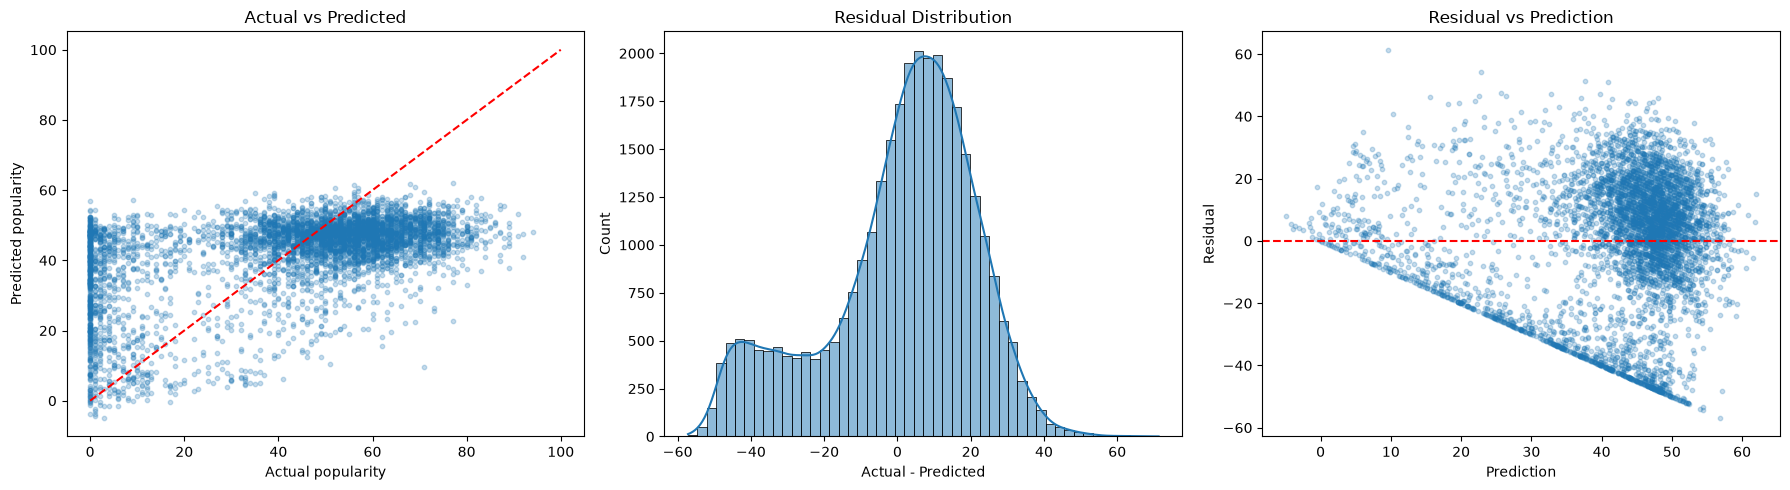

In [6]:
diagnostics = test_df[["track_id", "release_year", TARGET]].copy()
diagnostics["prediction"] = y_pred_final
diagnostics["residual"] = diagnostics[TARGET] - diagnostics["prediction"]
diagnostics["absolute_error"] = diagnostics["residual"].abs()
diagnostics["popularity_group"] = pd.cut(
    diagnostics[TARGET],
    bins=[-np.inf, 30, 50, 70, np.inf],
    labels=["low", "emerging", "medium", "high"],
)

error_by_group = diagnostics.groupby("popularity_group", observed=True).agg(
    Rows=("absolute_error", "size"),
    MAE=("absolute_error", "mean"),
    Bias=("residual", "mean"),
).reset_index()
display(error_by_group)

sample = diagnostics.sample(min(5000, len(diagnostics)), random_state=1512)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(sample[TARGET], sample["prediction"], alpha=0.25, s=10)
axes[0].plot([0, 100], [0, 100], "r--")
axes[0].set(title="Actual vs Predicted", xlabel="Actual popularity", ylabel="Predicted popularity")
sns.histplot(diagnostics["residual"], bins=50, kde=True, ax=axes[1])
axes[1].set(title="Residual Distribution", xlabel="Actual - Predicted", ylabel="Count")
axes[2].scatter(sample["prediction"], sample["residual"], alpha=0.25, s=10)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set(title="Residual vs Prediction", xlabel="Prediction", ylabel="Residual")
plt.tight_layout()
plt.show()

## 6. Feature importance

,Feature,Importance
0,release_year,0.141439
1,decade_2000,0.101077
2,decade_1950,0.098874
3,decade_2010,0.063499
4,release_month_12.0,0.057629
5,decade_1940,0.040165
6,decade_1990,0.040011
7,decade_1930,0.039856
8,explicit,0.032126
9,acousticness,0.028513


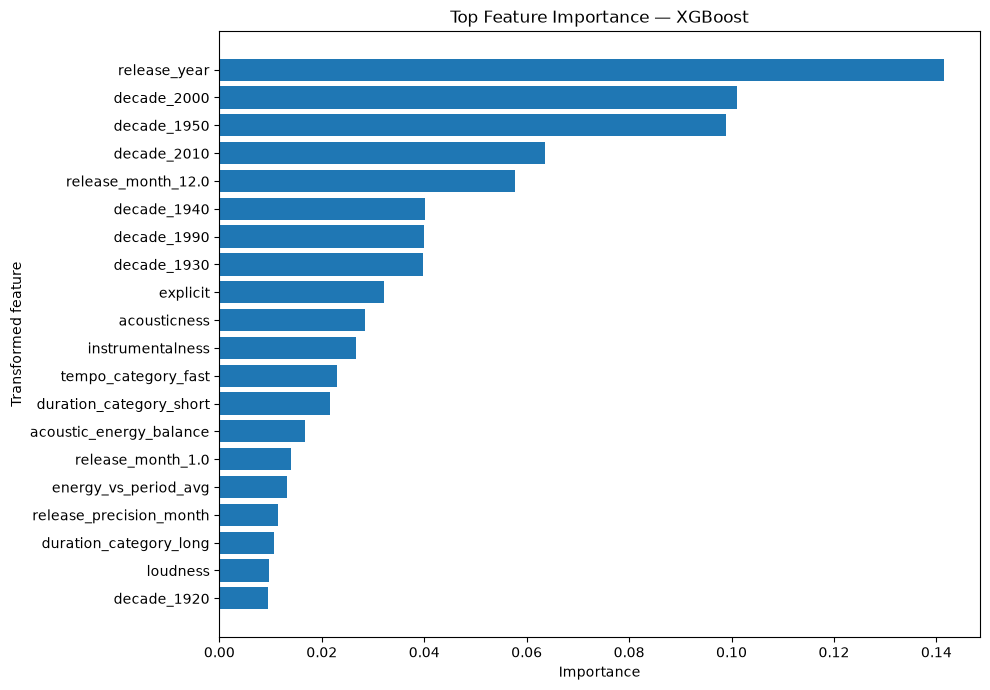

In [7]:
feature_importance = transformed_feature_importance(final_pipeline)
display(feature_importance.head(20))

top = feature_importance.head(20).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(top["Feature"], top["Importance"])
plt.title(f"Top Feature Importance — {FINAL_MODEL_NAME}")
plt.xlabel("Importance")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()

## 7. Save model, preprocessing, metrics và predictions

In [8]:
PIPELINE_PATH = ARTIFACT_DIR / "popularity_pipeline.joblib"
FEATURE_COLUMNS_PATH = ARTIFACT_DIR / "feature_columns.json"
METRICS_PATH = ARTIFACT_DIR / "metrics.json"
PREDICTIONS_PATH = EVALUATION_DIR / "hard_requirement_test_predictions.parquet"
IMPORTANCE_PATH = EVALUATION_DIR / "feature_importance.json"
METRICS_MIRROR_PATH = EVALUATION_DIR / "model_metrics.json"

metrics_payload = {
    "final_model": FINAL_MODEL_NAME,
    "selection_rule": "lowest engineered test RMSE, tie-break by MAE",
    "test_start_year": TEST_START_YEAR,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "raw_input_feature_count": len(RAW_INPUT_FEATURES),
    "model_feature_count": len(MODEL_FEATURES),
    "engineered_feature_count": len(EXPECTED_ENGINEERED_FEATURES),
    "final_test_metrics": final_test_metrics,
    "experiments": metrics_table.to_dict(orient="records"),
    "feature_engineering_effect": feature_effect.to_dict(orient="records"),
    "error_by_popularity_group": error_by_group.to_dict(orient="records"),
}

joblib.dump(final_pipeline, PIPELINE_PATH)
FEATURE_COLUMNS_PATH.write_text(json.dumps({
    "raw_input_features": RAW_INPUT_FEATURES,
    "model_features": MODEL_FEATURES,
    "engineered_features": EXPECTED_ENGINEERED_FEATURES,
    "transformed_feature_names": final_pipeline.named_steps["preprocessing"].get_feature_names_out().tolist(),
}, indent=2, ensure_ascii=False), encoding="utf-8")
METRICS_PATH.write_text(json.dumps(metrics_payload, indent=2, ensure_ascii=False), encoding="utf-8")
METRICS_MIRROR_PATH.write_text(json.dumps(metrics_payload, indent=2, ensure_ascii=False), encoding="utf-8")
diagnostics.to_parquet(PREDICTIONS_PATH, index=False)
IMPORTANCE_PATH.write_text(feature_importance.to_json(orient="records", indent=2), encoding="utf-8")

reloaded_pipeline = joblib.load(PIPELINE_PATH)
reloaded_pred = reloaded_pipeline.predict(X_test.head(5))
np.testing.assert_allclose(reloaded_pred, final_pipeline.predict(X_test.head(5)))

print(f"Pipeline: {PIPELINE_PATH}")
print(f"Metrics: {METRICS_PATH}")
print(f"Predictions: {PREDICTIONS_PATH}")
print(f"Feature columns: {FEATURE_COLUMNS_PATH}")

Pipeline: D:\Hitradar\hitradar-main\4.MODELS\hitradar_popularity\popularity_pipeline.joblib
Metrics: D:\Hitradar\hitradar-main\4.MODELS\hitradar_popularity\metrics.json
Predictions: D:\Hitradar\hitradar-main\4.MODELS\4.2.evaluation\hard_requirement_test_predictions.parquet
Feature columns: D:\Hitradar\hitradar-main\4.MODELS\hitradar_popularity\feature_columns.json


## 8. Insight, limitations và handoff

**Finding:** bảng experiment phía trên là kết quả mới từ 6 lần train thật; không tái sử dụng metric cũ.  
**Interpretation:** hiệu quả của Feature Engineering được kết luận bằng chênh lệch MAE/RMSE/R², không bằng feature importance đơn lẻ.  
**Impact:** final artifact chứa FeatureBuilder + encoder/scaler + estimator trong một pipeline, giảm train/inference mismatch.  
**Limitation:** popularity lịch sử chịu time bias; metric test 2019–2021 không chứng minh quan hệ nhân quả hoặc khả năng dự báo hit tương lai ngoài distribution.  
**Handoff:** Notebook 07 và FastAPI chỉ nhận 17 raw fields, load `popularity_pipeline.joblib`, rồi smoke test toàn luồng RAW INPUT → FEATURES → MODEL → PREDICTION.